# Figure B (ICML rebuttal): head collaboration dynamics

This notebook reproduces the new rebuttal Figure B from W&B scalar logs. The figure is not in `gfe23Z-2602.19143v1.pdf` yet; it was added after the report to show how three heads specialize by position and by value-feature alignment over training.

The attached `Figure-B.pdf` matches the W&B tag `ICML-minimal-transformer-small-init-orthogonal`, run `05c1tr5d`.

In [1]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from analysis.utils import (
    REPORT_HEAD_COLORS,
    REPORT_LEGEND_SIZE,
    REPORT_LINEWIDTH,
    fetch_runs,
    get_runs_data,
    style_report_axis,
    _config_to_dict,
)

SAVE_FIGURES = False
FIGURE_DIR = Path("analysis/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

NUM_HEADS = 3
NUM_SPANS = 3
SPLIT = "train"
HEAD_COLORS = REPORT_HEAD_COLORS


## W&B provenance

The merged branch introduced several tags around this experiment. The table checks which tags contain the per-head attention-mass and value-inner-product scalars needed for Figure B. The full one-layer tag is included here because it was added in the same branch, but it lacks the value-alignment scalars needed for the full two-row figure.

In [2]:
CANDIDATE_TAGS = [
    "ICML-minimal-transformer-small-init-orthogonal",
    "ICML-minimal-small-init",
    "ICML-minimal-model-updates",
    "ICML-full-1layer",
]


def _head_dynamics_metrics(split=SPLIT, num_heads=NUM_HEADS, num_spans=NUM_SPANS):
    attn_metrics = [
        f"{split}_attn_mass_head{h}_span{k}"
        for h in range(num_heads)
        for k in range(num_spans)
    ]
    value_metrics = [
        f"{split}_value_inner_head{h}_teacher{k}"
        for h in range(num_heads)
        for k in range(num_spans)
    ]
    return attn_metrics, value_metrics


def summarize_candidate_tags(tags):
    attn_metrics, value_metrics = _head_dynamics_metrics()
    rows = []
    for tag in tags:
        runs = sorted(fetch_runs(tags_any=[tag]), key=lambda run: run.created_at or "")
        df_attn = get_runs_data(runs, metrics=attn_metrics, include_config=False)
        df_value = get_runs_data(runs, metrics=value_metrics, include_config=False)
        rows.append(
            {
                "tag": tag,
                "runs": len(runs),
                "run_ids": ", ".join(run.id for run in runs),
                "states": ", ".join(sorted({run.state for run in runs})),
                "attention_scalars": "yes" if not df_attn.empty else "no",
                "value_scalars": "yes" if not df_value.empty else "no",
                "steps": (
                    f"{int(df_attn['_step'].min())}-{int(df_attn['_step'].max())}"
                    if not df_attn.empty
                    else "-"
                ),
            }
        )
    return pd.DataFrame(rows)


tag_summary = summarize_candidate_tags(CANDIDATE_TAGS)
display(tag_summary)


,tag,runs,run_ids,states,attention_scalars,value_scalars,steps
0,ICML-minimal-transformer-small-init-orthogonal,1,05c1tr5d,finished,yes,yes,0-1950
1,ICML-minimal-small-init,1,3cmn17ll,finished,yes,yes,0-1950
2,ICML-minimal-model-updates,1,w1ntb1bh,finished,yes,yes,0-1950
3,ICML-full-1layer,1,am9z61y2,finished,yes,no,0-1950


## Plotting helper

The top row plots each displayed head's attention mass on each teacher position group. The bottom row plots `<V_h, A*_k>`, the value-projection alignment with each teacher feature matrix. Heads are permuted by their final attention specialization so the displayed colors line up with Positions 1, 2, and 3.

In [3]:
def _filter_runs(runs, run_ids=None):
    if run_ids is None:
        return list(runs)
    keep = set(run_ids)
    return [run for run in runs if run.id in keep]


def _infer_head_perm(df_attn, split, num_heads, num_spans):
    run_id = df_attn["_run_id"].unique()[0]
    df_run = df_attn[df_attn["_run_id"] == run_id].sort_values("_step")
    last_row = df_run.iloc[-1]

    mass = np.zeros((num_heads, num_spans))
    for h in range(num_heads):
        for k in range(num_spans):
            col = f"{split}_attn_mass_head{h}_span{k}"
            if col in last_row.index:
                mass[h, k] = last_row[col]

    perm = []
    used = set()
    for k in range(num_spans):
        available = [h for h in range(num_heads) if h not in used]
        best_h = max(available, key=lambda h: mass[h, k])
        perm.append(best_h)
        used.add(best_h)
    return perm


def _save_figure(fig, save_name):
    if not save_name:
        return None
    save_path = FIGURE_DIR / f"{save_name}.pdf"
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    print(f"Saved {save_path}")
    return save_path


def plot_head_dynamics(
    tag,
    run_ids=None,
    save_name=None,
    split=SPLIT,
    num_heads=NUM_HEADS,
    num_spans=NUM_SPANS,
    head_colors=HEAD_COLORS,
    head_perm=None,
):
    tags = [tag] if isinstance(tag, str) else list(tag)
    runs = sorted(fetch_runs(tags_any=tags), key=lambda run: run.created_at or "")
    runs = _filter_runs(runs, run_ids=run_ids)
    if not runs:
        raise ValueError(f"No runs found for tag(s) {tags} and run_ids={run_ids}")

    print(f"Using {len(runs)} run(s):")
    for run in runs:
        print(f"  {run.id}  {run.name}  state={run.state}")

    attn_metrics, value_metrics = _head_dynamics_metrics(split, num_heads, num_spans)
    df_attn = get_runs_data(runs, metrics=attn_metrics, include_config=False)
    df_value = get_runs_data(runs, metrics=value_metrics, include_config=False)

    has_attn = not df_attn.empty
    has_value = not df_value.empty
    if not has_attn and not has_value:
        raise ValueError("The selected run(s) do not contain the Figure B scalar metrics.")

    if head_perm is None:
        head_perm = _infer_head_perm(df_attn, split, num_heads, num_spans) if has_attn else list(range(num_heads))
    print(f"Head permutation (display -> original): {head_perm}")

    nrows = int(has_attn) + int(has_value)
    fig, axes = plt.subplots(nrows, num_spans, figsize=(5.5 * num_spans, 4.5 * nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    row_idx = 0
    if has_attn:
        for run_id in df_attn["_run_id"].unique():
            df_run = df_attn[df_attn["_run_id"] == run_id].sort_values("_step")
            is_first = run_id == df_attn["_run_id"].unique()[0]
            alpha = 1.0 if df_attn["_run_id"].nunique() == 1 else 0.5
            for k in range(num_spans):
                ax = axes[row_idx, k]
                for h in range(num_heads):
                    col = f"{split}_attn_mass_head{head_perm[h]}_span{k}"
                    if col in df_run.columns:
                        ax.plot(
                            df_run["_step"],
                            df_run[col],
                            color=head_colors[h],
                            linewidth=REPORT_LINEWIDTH,
                            alpha=alpha,
                            label=f"Head {h + 1}" if is_first else None,
                        )
        for k in range(num_spans):
            ax = axes[row_idx, k]
            ax.set_xscale("log")
            ax.set_yscale("log")
            style_report_axis(
                ax,
                xlabel="Time",
                ylabel="Attention Mass" if k == 0 else None,
                title=f"Position ({k + 1})",
            )
        row_idx += 1

    if has_value:
        for run_id in df_value["_run_id"].unique():
            df_run = df_value[df_value["_run_id"] == run_id].sort_values("_step")
            is_first = run_id == df_value["_run_id"].unique()[0]
            alpha = 1.0 if df_value["_run_id"].nunique() == 1 else 0.5
            for k in range(num_spans):
                ax = axes[row_idx, k]
                for h in range(num_heads):
                    col = f"{split}_value_inner_head{head_perm[h]}_teacher{k}"
                    if col in df_run.columns:
                        ax.plot(
                            df_run["_step"],
                            df_run[col],
                            color=head_colors[h],
                            linewidth=REPORT_LINEWIDTH,
                            alpha=alpha,
                            label=f"Head {h + 1}" if is_first else None,
                        )
        for k in range(num_spans):
            ax = axes[row_idx, k]
            ax.set_xscale("log")
            style_report_axis(
                ax,
                xlabel="Time",
                ylabel="Value Inner Product" if k == 0 else None,
                title=f"Feature ({k + 1})",
            )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=num_heads,
        fontsize=REPORT_LEGEND_SIZE,
        frameon=True,
        bbox_to_anchor=(0.5, 1.02),
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    _save_figure(fig, save_name)
    plt.show()
    return fig, axes, {"attention": df_attn, "value": df_value, "head_perm": head_perm}


## Figure B

This is the plot corresponding to the attached rebuttal figure. Set `SAVE_FIGURES = True` to write `analysis/figures/figure-b-rebuttal-head-dynamics.pdf`.

Using 1 run(s):
  05c1tr5d  distinctive-sea-1968  state=finished
Head permutation (display -> original): [1, 2, 0]


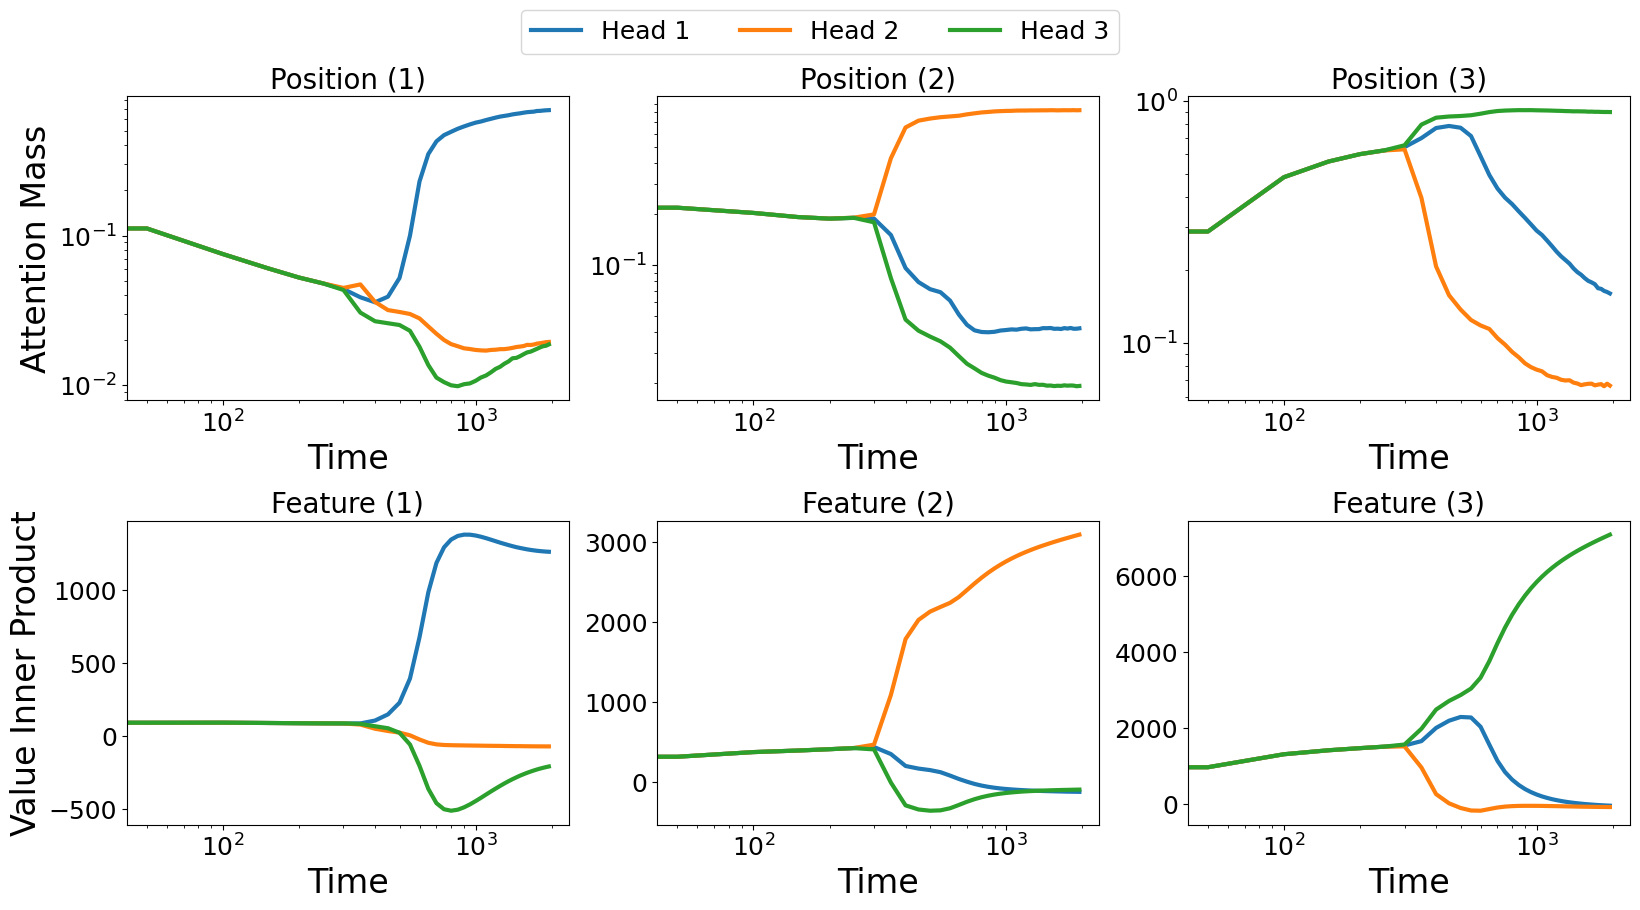

In [4]:
FIGURE_B_TAG = "ICML-minimal-transformer-small-init-orthogonal"
FIGURE_B_RUN_ID = "05c1tr5d"

fig, axes, figure_b_data = plot_head_dynamics(
    FIGURE_B_TAG,
    run_ids=[FIGURE_B_RUN_ID],
    save_name="figure-b-rebuttal-head-dynamics" if SAVE_FIGURES else None,
)


## Optional comparisons

The two model-update tags below contain the same Figure B scalar families and can be useful for ablations. They are disabled by default so a normal run of the notebook reproduces only the rebuttal figure.

In [5]:
RUN_OPTIONAL_COMPARISON = False

if RUN_OPTIONAL_COMPARISON:
    for tag in ["ICML-minimal-small-init", "ICML-minimal-model-updates"]:
        plot_head_dynamics(tag)
